# Gwas

Этот ipynb предназначен для работы с генетическими данными и резульатами, полученными после работы пайплайна

## Импорт библиотек и загрузка необходимых файлов

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import stats

In [ ]:
phenotypes = pd.read_csv("/home/user/papkamusik/AAAA/again/filtered_geno.csv")
genotypes = pd.read_csv("/home/user/papkamusik/action_folder/GWAS/voice_genotypes.csv", na_values=['./.'])

covariates = phenotypes[["call_id", "age", "gender"]]

На данный момент присутствуют только ковариаты возраста и пола испытуемых

In [84]:
df = phenotypes.merge(genotypes, on="call_id")
df = df.merge(covariates, on="call_id")

# Подготовка данных

In [85]:
snp_cols = df.columns[df.columns.str.startswith('rs')].tolist()
genotype_map = {'0/0': 0, '0/1': 1, '1/1': 2}

df[snp_cols] = df[snp_cols].apply(lambda col: col.map(genotype_map))

Отбор тех SNP у которых количество пропусков меньше 2%

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 51 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   call_id         52 non-null     object 
 1   gender_x        52 non-null     object 
 2   total_duration  52 non-null     float64
 3   f0_median       52 non-null     float64
 4   f0_std          52 non-null     float64
 5   f0_min          52 non-null     float64
 6   f0_max          52 non-null     float64
 7   f0_range        52 non-null     float64
 8   f1_median       52 non-null     float64
 9   f1_std          52 non-null     float64
 10  f1_min          52 non-null     float64
 11  f1_max          52 non-null     float64
 12  f1_range        52 non-null     float64
 13  f2_median       52 non-null     float64
 14  f2_std          52 non-null     float64
 15  f2_min          52 non-null     float64
 16  f2_max          52 non-null     float64
 17  f2_range        52 non-null     float

# Непосредственно GWAS

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests

# =========================
# 1. PREPROCESSING
# =========================

covariates["gender"] = covariates["gender"].str.lower().map({
    "female": 1,
    "male": 0
})

df = df.merge(covariates, on="call_id")

covars = [c for c in covariates.columns if c != "call_id"]

phenotype = "f0_median"

# =========================
# 2. SNP QC (call rate filter)
# =========================

call_rate_threshold = 0.95

valid_snps = [
    snp for snp in snp_cols
    if df[snp].notna().mean() >= call_rate_threshold
]

print(f"Remaining SNPs after QC: {len(valid_snps)}")

# 3. GWAS LOOP
results = []

for snp in tqdm(valid_snps):

    cols = [phenotype, snp] + covars
    sub_df = df[cols].dropna()

    n = len(sub_df)

    # минимальный размер выборки
    if n < 30:
        continue

    y = sub_df[phenotype]

    # MODEL 1 (no covariates)
    X1 = sm.add_constant(sub_df[[snp]])
    model1 = sm.OLS(y, X1).fit()

    # MODEL 2 (with covariates)
    X2 = sm.add_constant(sub_df[[snp] + covars])
    model2 = sm.OLS(y, X2).fit(cov_type='HC3')

    results.append([
        snp,
        phenotype,
        n,

        model1.params[snp],
        model1.pvalues[snp],

        model2.params[snp],
        model2.pvalues[snp]
    ])

# 4. RESULTS TABLE
gwas = pd.DataFrame(results, columns=[
    "SNP", "phenotype", "n",
    "beta_m1", "p_m1",
    "beta_m2", "p_m2"
])

# 5. MAIN ANALYSIS (MODEL 2)
gwas["p"] = gwas["p_m2"]
gwas["beta"] = gwas["beta_m2"]

# 6. MULTIPLE TESTING
alpha = 0.05

# Bonferroni
gwas["bonferroni_threshold"] = alpha / len(gwas)
gwas["bonferroni_significant"] = gwas["p"] < gwas["bonferroni_threshold"]

# FDR
gwas["fdr_p"] = multipletests(gwas["p"], method="fdr_bh")[1]
gwas["fdr_significant"] = gwas["fdr_p"] < 0.05

# 7. QUALITY METRICS
gwas["-log10(p)"] = -np.log10(gwas["p"])

# 8. SORTING
gwas = gwas.sort_values("p").reset_index(drop=True)

/tmp/ipykernel_30568/1714750924.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covariates["gender"] = covariates["gender"].str.lower().map({


Remaining SNPs after QC: 15


100%|██████████| 15/15 [00:00<00:00, 288.10it/s]


,SNP,phenotype,n,beta_m1,p_m1,beta_m2,p_m2,p,beta,bonferroni_threshold,bonferroni_significant,fdr_p,fdr_significant,-log10(p)
0,rs9568476,f0_median,52,9.152932,0.318047,-10.100930,0.029832,0.029832,-10.100930,0.003333,False,0.447475,False,1.525322
1,rs1516882,f0_median,52,-0.925539,0.930019,6.574475,0.115510,0.115510,6.574475,0.003333,False,0.689003,False,0.937381
2,rs13179411,f0_median,51,-1.954806,0.849697,5.803348,0.188897,0.188897,5.803348,0.003333,False,0.689003,False,0.723774
3,rs55972276,f0_median,52,-10.812001,0.466351,7.596789,0.241068,0.241068,7.596789,0.003333,False,0.689003,False,0.617860
4,rs8005994,f0_median,52,3.887269,0.707740,4.941705,0.255956,0.255956,4.941705,0.003333,False,0.689003,False,0.591835
5,rs72901035,f0_median,52,7.152607,0.560827,4.955123,0.275601,0.275601,4.955123,0.003333,False,0.689003,False,0.559719
6,rs12759783,f0_median,51,14.202169,0.169964,3.045298,0.443055,0.443055,3.045298,0.003333,False,0.804542,False,0.353543
7,rs11037611,f0_median,52,14.132681,0.150187,-3.106325,0.452365,0.452365,-3.106325,0.003333,False,0.804542,False,0.344511
8,rs314268,f0_median,51,0.553089,0.957224,2.986935,0.482725,0.482725,2.986935,0.003333,False,0.804542,False,0.316300
9,rs12003641,f0_median,52,6.396037,0.734650,-4.457853,0.607917,0.607917,-4.457853,0.003333,False,0.814365,False,0.216156


# ЭТАП 4. MANHATTAN PLOT

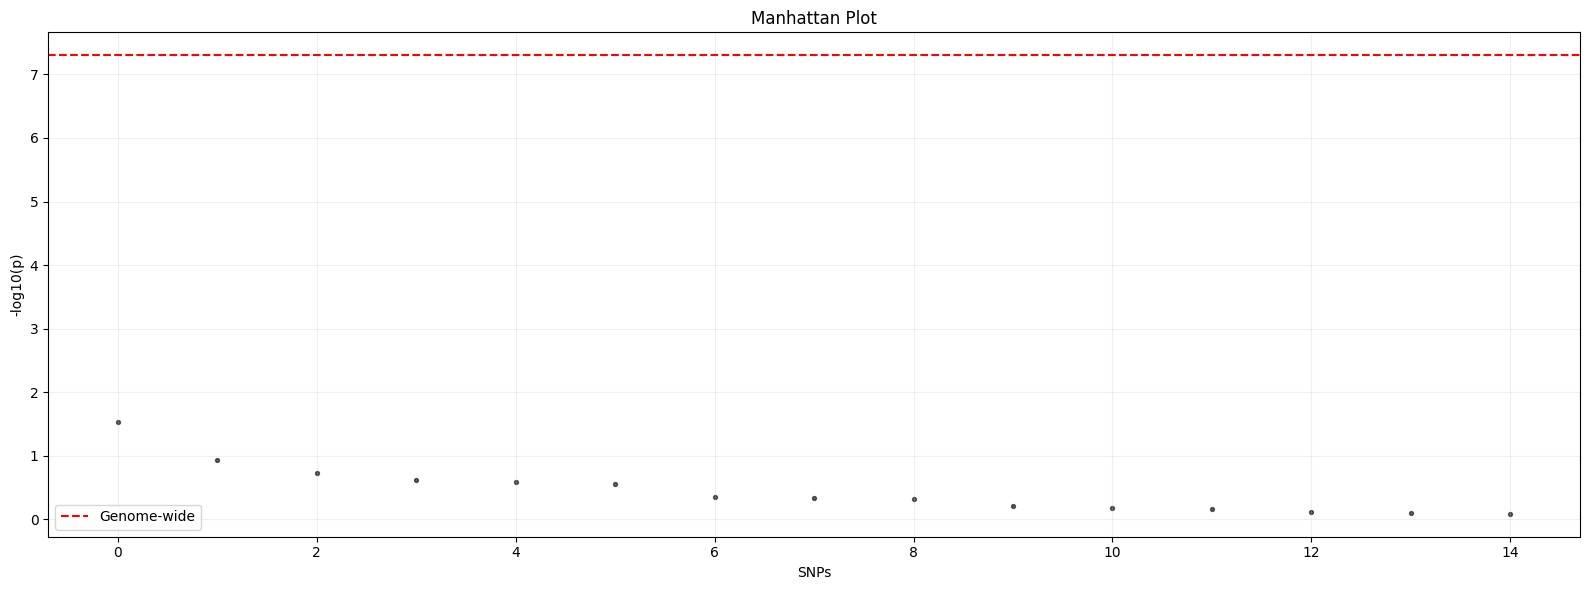

In [89]:
gwas["-log10(p)"] = -np.log10(gwas["p"])

plt.figure(figsize=(16, 6))

plt.scatter(
    np.arange(len(gwas)),
    gwas["-log10(p)"],
    c="black",
    s=8,
    alpha=0.6
)

plt.axhline(-np.log10(5e-8), color="red", linestyle="--", label="Genome-wide")

plt.xlabel("SNPs")
plt.ylabel("-log10(p)")
plt.title("Manhattan Plot")
plt.legend()

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# QQ PLOT

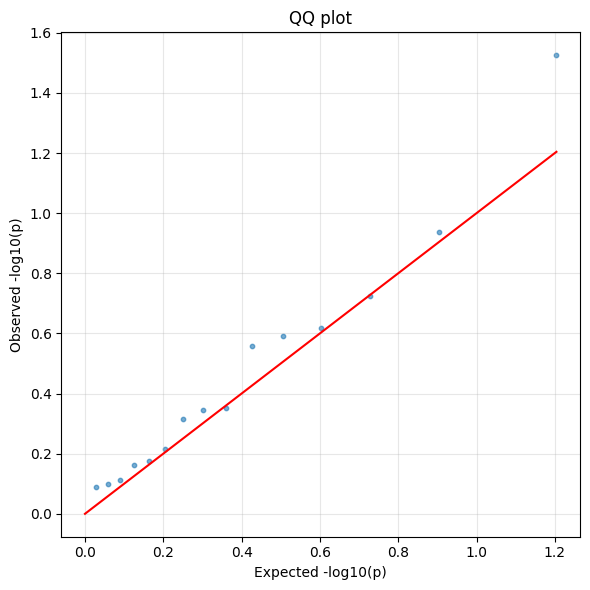

In [90]:
pvals = np.sort(gwas["p"].values)
expected = np.arange(1, len(pvals) + 1) / (len(pvals) + 1)

plt.figure(figsize=(6, 6))

plt.scatter(
    -np.log10(expected),
    -np.log10(pvals),
    s=10,
    alpha=0.6
)

max_val = max(-np.log10(pvals.max()), -np.log10(expected.min()))

plt.plot([0, max_val], [0, max_val], color="red")

plt.xlabel("Expected -log10(p)")
plt.ylabel("Observed -log10(p)")
plt.title("QQ plot")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Сделать multi-qwas и prs